# 🎬 Movie Rating Prediction with Python

## 📌 Data Science Internship Project

### 🎯 Objective
The objective of this project is to build a machine learning model that predicts movie ratings based on various movie features such as genres, cast, crew, budget, popularity, runtime, and other metadata.

### 🛠️ Tools & Technologies Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- Jupyter Notebook

### 📂 Dataset
- TMDB 5000 Movies Dataset
- TMDB 5000 Credits Dataset

In [7]:
# ============================================================
#                 IMPORT REQUIRED LIBRARIES
# ============================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Ignore Warning Messages
import warnings
warnings.filterwarnings("ignore")

# Visualization Style
plt.style.use("ggplot")

print("="*60)
print("✅ All required libraries imported successfully.")
print("="*60)

✅ All required libraries imported successfully.


# ============================================================
# LOAD THE DATASETS
# ============================================================

In this step, we load the **TMDB 5000 Movies** dataset and the **TMDB 5000 Credits** dataset into pandas DataFrames for further analysis.

In [8]:
# ============================================================
# Load the Datasets
# ============================================================

movies_df = pd.read_csv("../data/tmdb_5000_movies.csv")
credits_df = pd.read_csv("../data/tmdb_5000_credits.csv")

print("=" * 60)
print("Datasets loaded successfully!")
print("=" * 60)

Datasets loaded successfully!


# ============================================================
# DISPLAY FIRST 5 ROWS OF THE DATASETS
# ============================================================

In this step, we display the first five records of both datasets to understand their structure and available features.

In [9]:
# Display first 5 rows of Movies Dataset
print("=" * 60)
print("Movies Dataset (First 5 Rows)")
print("=" * 60)

movies_df.head()

Movies Dataset (First 5 Rows)


,budget,genres,homepage,id,keywords,original_language,original_title,overview,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,tagline,title,vote_average,vote_count
0,237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.avatarmovie.com/,19995,"[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,Avatar,"In the 22nd century, a paraplegic Marine is di...",150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Enter the World of Pandora.,Avatar,7.2,11800
1,300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...",http://disney.go.com/disneypictures/pirates/,285,"[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,Pirates of the Caribbean: At World's End,"Captain Barbossa, long believed to be dead, ha...",139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"At the end of the world, the adventure begins.",Pirates of the Caribbean: At World's End,6.9,4500
2,245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://www.sonypictures.com/movies/spectre/,206647,"[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,Spectre,A cryptic message from Bond’s past sends him o...,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,A Plan No One Escapes,Spectre,6.3,4466
3,250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...",http://www.thedarkknightrises.com/,49026,"[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,The Dark Knight Rises,Following the death of District Attorney Harve...,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Legend Ends,The Dark Knight Rises,7.6,9106
4,260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...",http://movies.disney.com/john-carter,49529,"[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,John Carter,"John Carter is a war-weary, former military ca...",43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,"Lost in our world, found in another.",John Carter,6.1,2124


# ==============================================================================
# DATASET INFORMATION
# ==============================================================================

In this step, we examine the structure of both datasets, including column names,
data types, and non-null values. This helps identify missing values and understand
the overall schema before preprocessing.

In [10]:
# ==============================================================================
# Dataset Information
# ==============================================================================

print("=" * 60)
print("Movies Dataset Information")
print("=" * 60)

movies_df.info()

print("\n" + "=" * 60)
print("Credits Dataset Information")
print("=" * 60)

credits_df.info()

Movies Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   budget                4803 non-null   int64  
 1   genres                4803 non-null   str    
 2   homepage              1712 non-null   str    
 3   id                    4803 non-null   int64  
 4   keywords              4803 non-null   str    
 5   original_language     4803 non-null   str    
 6   original_title        4803 non-null   str    
 7   overview              4800 non-null   str    
 8   popularity            4803 non-null   float64
 9   production_companies  4803 non-null   str    
 10  production_countries  4803 non-null   str    
 11  release_date          4802 non-null   str    
 12  revenue               4803 non-null   int64  
 13  runtime               4801 non-null   float64
 14  spoken_languages      4803 non-null   str    
 15  statu

# ==============================================================================
# CHECK MISSING VALUES
# ==============================================================================

In this step, we identify missing values in both datasets. Detecting null values
helps determine which columns require cleaning or preprocessing before model
development.

In [11]:
# ============================================================
# Missing Values in Movies Dataset
# ============================================================

print("=" * 60)
print("Missing Values - Movies Dataset")
print("=" * 60)

print(movies_df.isnull().sum())

print("\n" + "=" * 60)
print("Missing Values - Credits Dataset")
print("=" * 60)

credits_df.isnull().sum()

Missing Values - Movies Dataset
budget                     0
genres                     0
homepage                3091
id                         0
keywords                   0
original_language          0
original_title             0
overview                   3
popularity                 0
production_companies       0
production_countries       0
release_date               1
revenue                    0
runtime                    2
spoken_languages           0
status                     0
tagline                  844
title                      0
vote_average               0
vote_count                 0
dtype: int64

Missing Values - Credits Dataset


movie_id    0
title       0
cast        0
crew        0
dtype: int64

# HANDLE MISSING VALUES

======================================================================

In this step, we handle the missing values identified in the Movies dataset.
Proper handling of missing data improves data quality and ensures the dataset
is suitable for further analysis and machine learning model development.

In [12]:
# ============================================================
# Handle Missing Values
# ============================================================

# Drop the homepage column because it has too many missing values
movies_df.drop(columns=['homepage'], inplace=True)

movies_df['tagline'] = movies_df['tagline'].fillna('Not Available')
movies_df['overview'] = movies_df['overview'].fillna('No Overview')
movies_df['runtime'] = movies_df['runtime'].fillna(movies_df['runtime'].median())

# Remove rows with missing release_date
movies_df.dropna(subset=['release_date'], inplace=True)

print("=" * 60)
print("Missing values handled successfully.")
print("=" * 60)

# Verify that missing values have been handled
print("\nRemaining Missing Values:\n")
print(movies_df.isnull().sum())

Missing values handled successfully.

Remaining Missing Values:

budget                  0
genres                  0
id                      0
keywords                0
original_language       0
original_title          0
overview                0
popularity              0
production_companies    0
production_countries    0
release_date            0
revenue                 0
runtime                 0
spoken_languages        0
status                  0
tagline                 0
title                   0
vote_average            0
vote_count              0
dtype: int64


# EXPLORATORY DATA ANALYSIS (EDA)

======================================================================

In this section, we explore the dataset using descriptive statistics and
visualizations to understand the distribution, relationships, and key
patterns in the movie data before building the machine learning model.

In [13]:
# ============================================================
# Descriptive Statistics
# ============================================================

print("=" * 60)
print("Descriptive Statistics")
print("=" * 60)

movies_df.describe()

Descriptive Statistics


,budget,id,popularity,revenue,runtime,vote_average,vote_count
count,4.802000e+03,4802.000000,4802.000000,4.802000e+03,4802.000000,4802.000000,4802.000000
mean,2.905109e+07,57098.234902,21.496776,8.227777e+07,106.896501,6.093440,690.361724
std,4.072447e+07,88581.302370,31.818451,1.628697e+08,22.557033,1.191496,1234.674268
min,0.000000e+00,5.000000,0.000372,0.000000e+00,0.000000,0.000000,0.000000
25%,8.000000e+05,9013.750000,4.671734,0.000000e+00,94.000000,5.600000,54.000000
50%,1.500000e+07,14626.500000,12.924931,1.917498e+07,103.000000,6.200000,235.500000
75%,4.000000e+07,58589.750000,28.332017,9.291920e+07,117.750000,6.800000,737.000000
max,3.800000e+08,459488.000000,875.581305,2.787965e+09,338.000000,10.000000,13752.000000


In [14]:
import os

os.makedirs("images", exist_ok=True)

print("✅ Images folder created successfully.")

✅ Images folder created successfully.


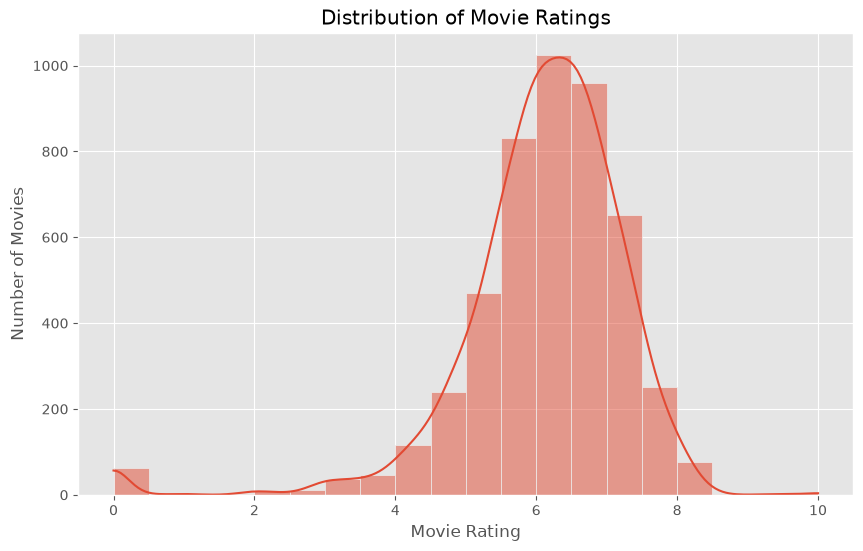

In [15]:
# ============================================================
# Distribution of Movie Ratings
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    movies_df["vote_average"],
    bins=20,
    kde=True
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Movie Rating")
plt.ylabel("Number of Movies")
plt.savefig("images/rating_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

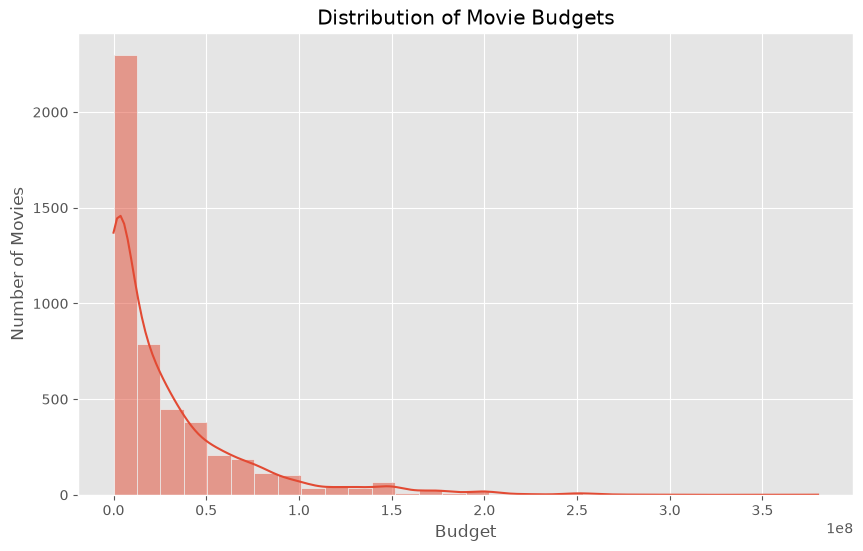

In [32]:
# ============================================================
# Budget Distribution
# ============================================================

plt.figure(figsize=(10, 6))

sns.histplot(
    movies_df["budget"],
    bins=30,
    kde=True
)

plt.title("Distribution of Movie Budgets")
plt.xlabel("Budget")
plt.ylabel("Number of Movies")
plt.savefig("images/budget_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

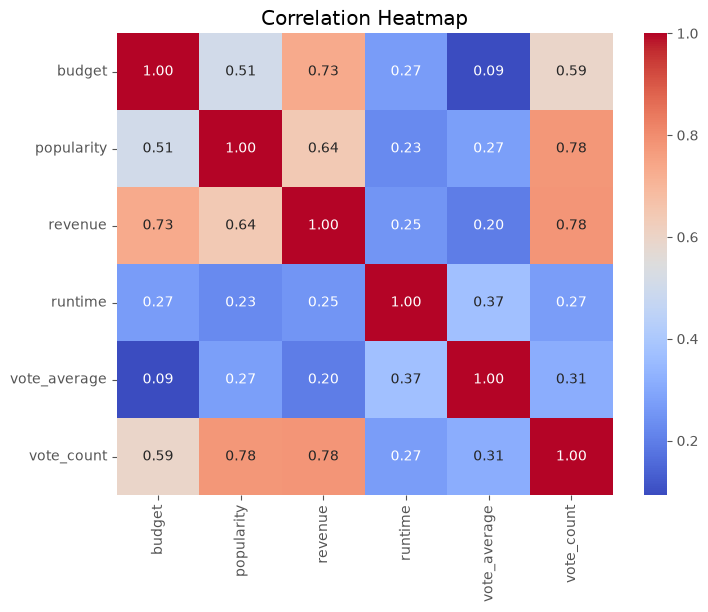

In [33]:
# ============================================================
# Correlation Heatmap
# ============================================================

plt.figure(figsize=(8, 6))

numeric_columns = [
    "budget",
    "popularity",
    "revenue",
    "runtime",
    "vote_average",
    "vote_count"
]

sns.heatmap(
    movies_df[numeric_columns].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")
plt.savefig("images/correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()

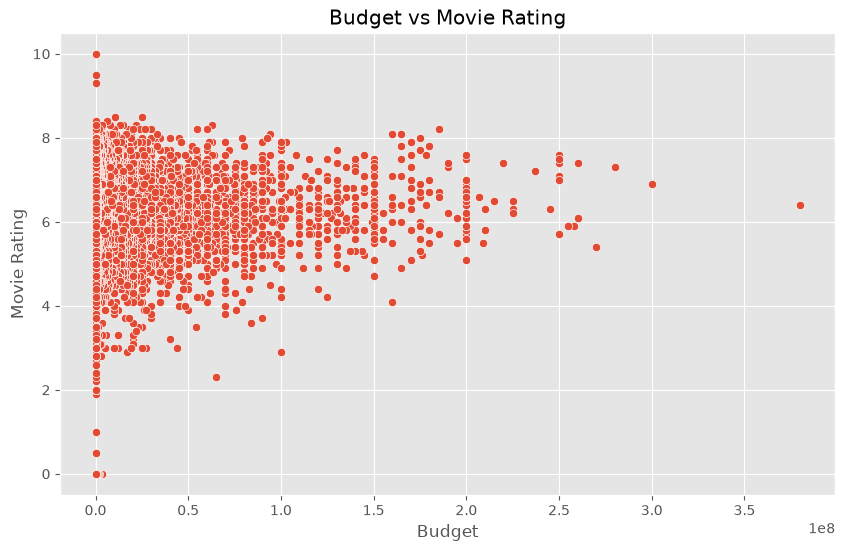

In [34]:
# ============================================================
# Budget vs Movie Rating
# ============================================================

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=movies_df,
    x="budget",
    y="vote_average"
)

plt.title("Budget vs Movie Rating")
plt.xlabel("Budget")
plt.ylabel("Movie Rating")
plt.savefig("images/budget_vs_rating.png", dpi=300, bbox_inches="tight")
plt.show()

# FEATURE ENGINEERING

======================================================================

In this section, we prepare the dataset for machine learning by merging
the Movies and Credits datasets and extracting the most relevant
features such as genres, cast, crew, and other attributes required for
movie rating prediction.

In [19]:
# ============================================================
# Merge Movies and Credits Datasets
# ============================================================

movies_df = movies_df.merge(
    credits_df,
    left_on="id",
    right_on="movie_id"
)

print("=" * 60)
print("Datasets merged successfully!")
print("=" * 60)

print("Merged Dataset Shape:", movies_df.shape)

Datasets merged successfully!
Merged Dataset Shape: (4802, 23)


In [20]:
# ============================================================
# Display Columns of the Merged Dataset
# ============================================================

print("=" * 60)
print("Merged Dataset Columns")
print("=" * 60)

print(movies_df.columns)

Merged Dataset Columns
Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title_x', 'vote_average',
       'vote_count', 'movie_id', 'title_y', 'cast', 'crew'],
      dtype='str')


In [21]:
# ============================================================
# Remove Duplicate Columns
# ============================================================

movies_df.drop(columns=["movie_id", "title_y"], inplace=True)

movies_df.rename(columns={"title_x": "title"}, inplace=True)

print("=" * 60)
print("Duplicate columns removed successfully!")
print("=" * 60)

print("Updated Shape:", movies_df.shape)
print("\nUpdated Columns:\n")
print(movies_df.columns)

Duplicate columns removed successfully!
Updated Shape: (4802, 21)

Updated Columns:

Index(['budget', 'genres', 'id', 'keywords', 'original_language',
       'original_title', 'overview', 'popularity', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'vote_average',
       'vote_count', 'cast', 'crew'],
      dtype='str')


In [22]:
# ============================================================
# Extract Top 3 Actors
# ============================================================

import ast

def extract_top_actors(cast_text):
    try:
        cast_list = ast.literal_eval(cast_text)
        actors = [person["name"] for person in cast_list[:3]]
        return ", ".join(actors)
    except:
        return "Unknown"

movies_df["top_actors"] = movies_df["cast"].apply(extract_top_actors)

print("=" * 60)
print("Top 3 actors extracted successfully!")
print("=" * 60)

movies_df[["title", "top_actors"]].head()

Top 3 actors extracted successfully!


,title,top_actors
0,Avatar,"Sam Worthington, Zoe Saldana, Sigourney Weaver"
1,Pirates of the Caribbean: At World's End,"Johnny Depp, Orlando Bloom, Keira Knightley"
2,Spectre,"Daniel Craig, Christoph Waltz, Léa Seydoux"
3,The Dark Knight Rises,"Christian Bale, Michael Caine, Gary Oldman"
4,John Carter,"Taylor Kitsch, Lynn Collins, Samantha Morton"


In [23]:
# ============================================================
# Extract Director
# ============================================================

def extract_director(crew_text):
    try:
        crew_list = ast.literal_eval(crew_text)

        for person in crew_list:
            if person["job"] == "Director":
                return person["name"]

        return "Unknown"

    except:
        return "Unknown"


movies_df["director"] = movies_df["crew"].apply(extract_director)

print("=" * 60)
print("Director extracted successfully!")
print("=" * 60)

movies_df[["title", "director"]].head()

Director extracted successfully!


,title,director
0,Avatar,James Cameron
1,Pirates of the Caribbean: At World's End,Gore Verbinski
2,Spectre,Sam Mendes
3,The Dark Knight Rises,Christopher Nolan
4,John Carter,Andrew Stanton


In [24]:
# ============================================================
# Extract Genres
# ============================================================

def extract_genres(genre_text):
    try:
        genre_list = ast.literal_eval(genre_text)
        genres = [genre["name"] for genre in genre_list]
        return ", ".join(genres)
    except:
        return "Unknown"


movies_df["genres"] = movies_df["genres"].apply(extract_genres)

print("=" * 60)
print("Genres extracted successfully!")
print("=" * 60)

movies_df[["title", "genres"]].head()

Genres extracted successfully!


,title,genres
0,Avatar,"Action, Adventure, Fantasy, Science Fiction"
1,Pirates of the Caribbean: At World's End,"Adventure, Fantasy, Action"
2,Spectre,"Action, Adventure, Crime"
3,The Dark Knight Rises,"Action, Crime, Drama, Thriller"
4,John Carter,"Action, Adventure, Science Fiction"


In [25]:
# ============================================================
# Select Features for Machine Learning
# ============================================================

ml_df = movies_df[[
    "budget",
    "popularity",
    "runtime",
    "vote_count",
    "vote_average"
]]

print("=" * 60)
print("Machine Learning Dataset Created")
print("=" * 60)

print("Shape:", ml_df.shape)

ml_df.head()

Machine Learning Dataset Created
Shape: (4802, 5)


,budget,popularity,runtime,vote_count,vote_average
0,237000000,150.437577,162.0,11800,7.2
1,300000000,139.082615,169.0,4500,6.9
2,245000000,107.376788,148.0,4466,6.3
3,250000000,112.312950,165.0,9106,7.6
4,260000000,43.926995,132.0,2124,6.1


In [26]:
# ============================================================
# Define Features (X) and Target (y)
# ============================================================

X = ml_df.drop("vote_average", axis=1)

y = ml_df["vote_average"]

print("=" * 60)
print("Features and Target Created")
print("=" * 60)

print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features and Target Created
Features Shape : (4802, 4)
Target Shape   : (4802,)


In [27]:
# ============================================================
# Split Dataset into Training and Testing Sets
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("=" * 60)
print("Dataset Split Successfully")
print("=" * 60)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)
print("Training Target   :", y_train.shape)
print("Testing Target    :", y_test.shape)

Dataset Split Successfully
Training Features : (3841, 4)
Testing Features  : (961, 4)
Training Target   : (3841,)
Testing Target    : (961,)


In [28]:
# ============================================================
# Train Linear Regression Model
# ============================================================

from sklearn.linear_model import LinearRegression

# Create the model
lr_model = LinearRegression()

# Train the model
lr_model.fit(X_train, y_train)

print("=" * 60)
print("Linear Regression Model Trained Successfully")
print("=" * 60)

Linear Regression Model Trained Successfully


In [29]:
# ============================================================
# Make Predictions
# ============================================================

y_pred = lr_model.predict(X_test)

print("=" * 60)
print("Predictions Generated Successfully")
print("=" * 60)

print("First 10 Predicted Ratings:")
print(y_pred[:10])

Predictions Generated Successfully
First 10 Predicted Ratings:
[5.76164245 6.01594454 5.99171445 5.9655482  6.99144848 6.13778689
 5.95097761 6.39201577 5.95518043 6.0295761 ]


In [30]:
# ============================================================
# Evaluate Linear Regression Model
# ============================================================

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("=" * 60)
print("Linear Regression Model Evaluation")
print("=" * 60)

print(f"Mean Absolute Error (MAE) : {mae:.4f}")
print(f"Mean Squared Error (MSE)  : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE) : {rmse:.4f}")
print(f"R² Score : {r2:.4f}")

Linear Regression Model Evaluation
Mean Absolute Error (MAE) : 0.7360
Mean Squared Error (MSE)  : 1.1855
Root Mean Squared Error (RMSE) : 1.0888
R² Score : 0.1240


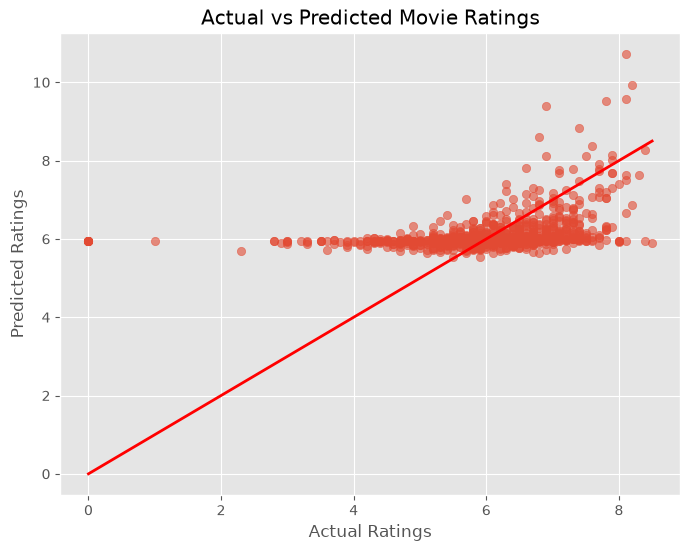

In [35]:
# ============================================================
# Actual vs Predicted Ratings
# ============================================================

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Movie Ratings")
plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.savefig("images/actual_vs_predicted.png", dpi=300, bbox_inches="tight")
plt.show()

# PROJECT CONCLUSION

==============================================================

In this project, a Linear Regression model was developed to predict movie ratings using numerical features such as budget, popularity, runtime, and vote count.

The workflow included data loading, preprocessing, exploratory data analysis (EDA), feature engineering, model training, prediction, and performance evaluation.

The model achieved the following evaluation metrics:

- Mean Absolute Error (MAE): 0.7360
- Mean Squared Error (MSE): 1.1855
- Root Mean Squared Error (RMSE): 1.0888
- R² Score: 0.1240

The low R² score indicates that these numerical features alone are not sufficient to accurately predict movie ratings. Incorporating additional information such as genres, directors, actors, keywords, and textual features could significantly improve model performance.

Overall, this project demonstrates the complete machine learning workflow, from data preprocessing to model evaluation, and provides a strong foundation for developing more advanced movie recommendation and rating prediction systems.